In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.sparse import hstack
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from wordcloud import WordCloud, STOPWORDS

import re
# Tutorial about Python regular expressions: https://pymotw.com/2/re/

import pickle
from tqdm import tqdm
import os

#from plotly import plotly
import plotly.offline as offline
import plotly.graph_objs as go
offline.init_notebook_mode()
from collections import Counter

##  <span style='color:Blue'> 1. Loading Data </span>

In [ ]:
data  = pd.read_csv(r'C:\Users\losetty\Desktop\Data Files\preprocessed_data.csv', nrows=50000)
data.head(5)

,school_state,teacher_prefix,project_grade_category,teacher_number_of_previously_posted_projects,project_is_approved,clean_categories,clean_subcategories,essay,price
0,ca,mrs,grades_prek_2,53,1,math_science,appliedsciences health_lifescience,i fortunate enough use fairy tale stem kits cl...,725.05
1,ut,ms,grades_3_5,4,1,specialneeds,specialneeds,imagine 8 9 years old you third grade classroo...,213.03
2,ca,mrs,grades_prek_2,10,1,literacy_language,literacy,having class 24 students comes diverse learner...,329.00
3,ga,mrs,grades_prek_2,2,1,appliedlearning,earlydevelopment,i recently read article giving students choice...,481.04
4,wa,mrs,grades_3_5,2,1,literacy_language,literacy,my students crave challenge eat obstacles brea...,17.74


In [ ]:
index = data.index
number_of_rows = len(index)
number_of_rows

50000

##  <span style='color:Blue'> Sentiment scores(preprocessed_essay) </span>

Ref: https://analyticsindiamag.com/sentiment-analysis-made-easy-using-vader/

SentimentIntensityAnalyzer() is an object and polarity_scores is a method which will  give scores of the following categories:

Positive
Negative
Neutral
Compound
The compound score is the sum of positive, negative & neutral scores which is then normalized between -1(most extreme negative) and +1 (most extreme positive).

In [ ]:
#Ref: https://www.kaggle.com/nikhilparmar9/decision-tree-donorschoose-dataset#PERFORMING-SENTIMENT-ANALYSIS
#https://github.com/AnveshAeturi/Decision-Tree-on-Donors-Choose-Dataset/blob/master/8_DonorsChoose_DT.ipynb

sid = SentimentIntensityAnalyzer()
negitive = []
positive = []
neutral = []
compound = []
for i in tqdm(data['essay']):
    j = sid.polarity_scores(i)['neg']
    k = sid.polarity_scores(i)['neu']
    l = sid.polarity_scores(i)['pos']
    m = sid.polarity_scores(i)['compound']
    negitive.append(j)
    positive.append(k)
    neutral.append(l)
    compound.append(m)




100%|███████████████████████████████████████████████████████████████████████████| 50000/50000 [06:09<00:00, 135.20it/s]


In [ ]:
data['Negitive'] = negitive
data['Positive'] = positive
data['Neutral'] = neutral
data['Compound'] = compound

In [ ]:
data.head(1)

,school_state,teacher_prefix,project_grade_category,teacher_number_of_previously_posted_projects,project_is_approved,clean_categories,clean_subcategories,essay,price,Negitive,Positive,Neutral,Compound
0,ca,mrs,grades_prek_2,53,1,math_science,appliedsciences health_lifescience,i fortunate enough use fairy tale stem kits cl...,725.05,0.013,0.783,0.205,0.9867


In [ ]:
#Imbalance data
data["project_is_approved"].value_counts()

1    41993
0     8007
Name: project_is_approved, dtype: int64

In [ ]:
data.columns

Index(['school_state', 'teacher_prefix', 'project_grade_category',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'clean_categories', 'clean_subcategories', 'essay', 'price', 'Negitive',
       'Positive', 'Neutral', 'Compound'],
      dtype='object')

CATEGORICAL

'school_state',
'teacher_prefix',
'project_grade_category',
'clean_categories',
'clean_subcategories',

NUMERICAL

'teacher_number_of_previously_posted_projects',
'price'


###  <span style='color:Blue'> New Features Added:</span>
sentiment score's of each of the essay : numerical data(positive , negative, neutral)

TEXT

'essay',

TARGET

'project_is_approved',


###  <span style='color:Blue'>Data split </span>

In [ ]:
y = data['project_is_approved'].values
x = data.drop(['project_is_approved'], axis=1)
x.head(1)

,school_state,teacher_prefix,project_grade_category,teacher_number_of_previously_posted_projects,clean_categories,clean_subcategories,essay,price,Negitive,Positive,Neutral,Compound
0,ca,mrs,grades_prek_2,53,math_science,appliedsciences health_lifescience,i fortunate enough use fairy tale stem kits cl...,725.05,0.013,0.783,0.205,0.9867


In [ ]:
# train test split using stratified sampling

#Going to use GridSearchCV, made the dataset split in to train and the test sets only.sklearn creates cv dataset internally for cv.

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, stratify=y,random_state = 42)
print(x_train.shape, y_train.shape)

(33500, 12) (33500,)


In [ ]:
print(x_test.shape, y_test.shape)

(16500, 12) (16500,)


# 2. Vectorizing Text data

## 2.1 Bag of words

In [ ]:
preprocessed_essays = x_train['essay'].values

In [ ]:
# We are considering only the words which appeared in at least 10 documents(rows or projects).
# CountVectorizer implements both tokenization and occurrence;counting in a single class used to transform a given text into a
#vector on the basis of the frequency (count) of each word that occurs in the entire text.
vectorizer = CountVectorizer(min_df=10)
x_train_essaytext_bow = vectorizer.fit_transform(preprocessed_essays)# to compute BOW representation
print("Shape of matrix after one hot encodig ",x_train_essaytext_bow.shape)#After BOW Vectorization ,matrix shape


x_test_essaytext_bow = vectorizer.transform(x_test['essay'].values)
print("x_test_essay_bow matrix shape after one hot encodig ",x_test_essaytext_bow.shape)

Shape of matrix after one hot encodig  (33500, 10338)
x_test_essay_bow matrix shape after one hot encodig  (16500, 10338)


In [ ]:
# you can vectorize the title also
# before you vectorize the title make sure you preprocess it

## <span style='color:Blue'>2.2 TFIDF vectorizer </span>

In [ ]:
vectorizer = TfidfVectorizer(min_df=10)
x_train_essaytext_tfidf = vectorizer.fit_transform(preprocessed_essays)#x_train_essaytext_tfidf
print("Shape of matrix after one hot encodig ",x_train_essaytext_tfidf.shape)


# test data
x_test_essaytext_tfidf = vectorizer.transform(x_test['essay'].values)
print("x_test_essay_tfidf matrix shape after one hot encodig ",x_test_essaytext_tfidf.shape)

Shape of matrix after one hot encodig  (33500, 10338)
x_test_essay_tfidf matrix shape after one hot encodig  (16500, 10338)


## 2.3 Using Pretrained Models: Avg W2V

In [ ]:
'''
# Reading glove vectors in python: https://stackoverflow.com/a/38230349/4084039
def loadGloveModel(gloveFile):
    print ("Loading Glove Model")
    f = open(gloveFile,'r', encoding="utf8")
    model = {}
    for line in tqdm(f):
        splitLine = line.split()
        word = splitLine[0]
        embedding = np.array([float(val) for val in splitLine[1:]])
        model[word] = embedding
    print ("Done.",len(model)," words loaded!")
    return model
model = loadGloveModel('glove.42B.300d.txt')

# ============================
Output:

Loading Glove Model
1917495it [06:32, 4879.69it/s]
Done. 1917495  words loaded!

# ============================

words = []
for i in preproced_texts:
    words.extend(i.split(' '))

for i in preproced_titles:
    words.extend(i.split(' '))
print("all the words in the coupus", len(words))
words = set(words)
print("the unique words in the coupus", len(words))

inter_words = set(model.keys()).intersection(words)
print("The number of words that are present in both glove vectors and our coupus", \
      len(inter_words),"(",np.round(len(inter_words)/len(words)*100,3),"%)")

words_courpus = {}
words_glove = set(model.keys())
for i in words:
    if i in words_glove:
        words_courpus[i] = model[i]
print("word 2 vec length", len(words_courpus))


# stronging variables into pickle files python: http://www.jessicayung.com/how-to-use-pickle-to-save-and-load-variables-in-python/

import pickle
with open('glove_vectors', 'wb') as f:
    pickle.dump(words_courpus, f)


'''

'\n# Reading glove vectors in python: https://stackoverflow.com/a/38230349/4084039\ndef loadGloveModel(gloveFile):\n    print ("Loading Glove Model")\n    f = open(gloveFile,\'r\', encoding="utf8")\n    model = {}\n    for line in tqdm(f):\n        splitLine = line.split()\n        word = splitLine[0]\n        embedding = np.array([float(val) for val in splitLine[1:]])\n        model[word] = embedding\n    print ("Done.",len(model)," words loaded!")\n    return model\nmodel = loadGloveModel(\'glove.42B.300d.txt\')\n\n# ============================\nOutput:\n    \nLoading Glove Model\n1917495it [06:32, 4879.69it/s]\nDone. 1917495  words loaded!\n\n# ============================\n\nwords = []\nfor i in preproced_texts:\n    words.extend(i.split(\' \'))\n\nfor i in preproced_titles:\n    words.extend(i.split(\' \'))\nprint("all the words in the coupus", len(words))\nwords = set(words)\nprint("the unique words in the coupus", len(words))\n\ninter_words = set(model.keys()).intersection(word

In [ ]:
# storing variables into pickle files python: http://www.jessicayung.com/how-to-use-pickle-to-save-and-load-variables-in-python/
# make sure you have the glove_vectors file
with open(r'C:\Users\losetty\Desktop\Data Files\glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())

In [ ]:
# average Word2Vec
# compute average word2vec for each review.
avg_w2v_vectors = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(preprocessed_essays): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    cnt_words =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if word in glove_words:
            vector += model[word]
            cnt_words += 1
    if cnt_words != 0:
        vector /= cnt_words
    avg_w2v_vectors.append(vector)

print(len(avg_w2v_vectors))
print(len(avg_w2v_vectors[0]))

100%|██████████████████████████████████████████████████████████████████████████| 33500/33500 [00:10<00:00, 3325.65it/s]

33500
300


## <span style='color:Blue'>2.4 Using Pretrained Models: TFIDF weighted W2V </span>

In [ ]:
# S = ["abc def pqr", "def def def abc", "pqr pqr def"]

# TFIDF weighted W2V and TFIDF W2V both are same

tfidf_model = TfidfVectorizer()
tfidf_model.fit(preprocessed_essays)
# we are converting a dictionary with word as a key, and the idf as a value
dictionary = dict(zip(tfidf_model.get_feature_names(), list(tfidf_model.idf_)))
tfidf_words = set(tfidf_model.get_feature_names())

In [ ]:
x_train_tfidf_w2v_vectors = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(preprocessed_essays): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    x_train_tfidf_w2v_vectors.append(vector)

print(len(x_train_tfidf_w2v_vectors))
print(len(x_train_tfidf_w2v_vectors[0]))

100%|███████████████████████████████████████████████████████████████████████████| 33500/33500 [01:13<00:00, 455.73it/s]

33500
300


In [ ]:
x_test_tfidf_w2v_vectors = []; # the avg-w2v for each sentence/review is stored in this list
for sentence in tqdm(x_test['essay'].values): # for each review/sentence
    vector = np.zeros(300) # as word vectors are of zero length
    tf_idf_weight =0; # num of words with a valid vector in the sentence/review
    for word in sentence.split(): # for each word in a review/sentence
        if (word in glove_words) and (word in tfidf_words):
            vec = model[word] # getting the vector for each word
            # here we are multiplying idf value(dictionary[word]) and the tf value((sentence.count(word)/len(sentence.split())))
            tf_idf = dictionary[word]*(sentence.count(word)/len(sentence.split())) # getting the tfidf value for each word
            vector += (vec * tf_idf) # calculating tfidf weighted w2v
            tf_idf_weight += tf_idf
    if tf_idf_weight != 0:
        vector /= tf_idf_weight
    x_test_tfidf_w2v_vectors.append(vector)

print(len(x_test_tfidf_w2v_vectors))
print(len(x_test_tfidf_w2v_vectors[0]))

100%|███████████████████████████████████████████████████████████████████████████| 16500/16500 [00:37<00:00, 438.29it/s]

16500
300


#  <span style='color:Blue'> 2. Vectorizing Categorical Features </span>

In [ ]:
# provided we did the cleaning
vectorizer = CountVectorizer(binary=True)
x_train_school_state_ohe = vectorizer.fit_transform(x_train['school_state'].values)
print("Shape of matrix after one hot encodig ",x_train_school_state_ohe.shape)

x_test_school_state_ohe = vectorizer.transform(x_test['school_state'].values)
print("x_test matrix shape after one hot encodig ",x_test_school_state_ohe.shape)

Shape of matrix after one hot encodig  (33500, 51)
x_test matrix shape after one hot encodig  (16500, 51)


In [ ]:
# convert 'teacher_prefix' to vectors

x_train_teacher_prefix_ohe=vectorizer.fit_transform(x_train['teacher_prefix'].values)
print("matrix shape after one hot encoding",x_train_teacher_prefix_ohe.shape)

x_test_teacher_prefix_ohe=vectorizer.transform(x_test['teacher_prefix'].values)
print("x_test matrix shape after one hot encoding",x_test_teacher_prefix_ohe.shape)

matrix shape after one hot encoding (33500, 5)
x_test matrix shape after one hot encoding (16500, 5)


In [ ]:
#convert 'project_grade_category' to vectors

x_train_project_grade_category_ohe=vectorizer.fit_transform(x_train['project_grade_category'].values)
print("matrix shape after one hot encoding",x_train_project_grade_category_ohe.shape)


x_test_project_grade_category_ohe=vectorizer.fit_transform(x_test['project_grade_category'].values)
print("matrix shape after one hot encoding",x_test_project_grade_category_ohe.shape)

matrix shape after one hot encoding (33500, 4)
matrix shape after one hot encoding (16500, 4)


In [ ]:
# convert 'clean_categories' to vectors
x_train_clean_categories_ohe =  vectorizer.fit_transform(x_train['clean_categories'].values)
print("Shape of matrix after one hot encodig ",x_train_clean_categories_ohe.shape)

x_test_clean_categories_ohe =  vectorizer.transform(x_test['clean_categories'].values)
print("Shape of matrix after one hot encodig ",x_test_clean_categories_ohe.shape)

Shape of matrix after one hot encodig  (33500, 9)
Shape of matrix after one hot encodig  (16500, 9)


In [ ]:
# convert 'clean_subcategories' to vectors
x_train_clean_subcategories_ohe =  vectorizer.fit_transform(x_train['clean_subcategories'].values)
print("Shape of matrix after one hot encodig ",x_train_clean_subcategories_ohe.shape)

x_test_clean_subcategories_ohe =  vectorizer.transform(x_test['clean_subcategories'].values)
print("Shape of matrix after one hot encodig ",x_test_clean_subcategories_ohe.shape)

Shape of matrix after one hot encodig  (33500, 30)
Shape of matrix after one hot encodig  (16500, 30)


###  Standardize Numerical Features

Standardization Equation

![image.png](attachment:image.png)

After standardization, the original distribution remains same and it doesn't mean distribution changed to Gauusian normal distribution

In [ ]:
# price

standardization = StandardScaler()# computes mean and standard deviation of the data when used with fit
x_train_price_standardization= standardization.fit_transform(x_train['price'].values.reshape(-1, 1))# transform performs standardization
print(x_train_price_standardization.shape)

x_test_price_standardization= standardization.transform(x_test['price'].values.reshape(-1, 1))
print(x_test_price_standardization.shape)

(33500, 1)
(16500, 1)


In [ ]:
#teacher_number_of_previously_posted_projects

x_train_teacher_previous_posted_projs_total_standardization= standardization.fit_transform(x_train['teacher_number_of_previously_posted_projects'].values.reshape(-1, 1))
print(x_train_teacher_previous_posted_projs_total_standardization.shape)

x_test_teacher_previous_posted_projs_total_standardization= standardization.transform(x_test['teacher_number_of_previously_posted_projects'].values.reshape(-1, 1))
print(x_test_teacher_previous_posted_projs_total_standardization.shape)

(33500, 1)
(16500, 1)


In [ ]:
# Postive

x_train_postive_standardization=standardization.fit_transform(x_train['Positive'].values.reshape(-1,1))
print(x_train_postive_standardization.shape)

x_test_postive_standardization=standardization.transform(x_test['Positive'].values.reshape(-1,1))
print(x_test_postive_standardization.shape)

(33500, 1)
(16500, 1)


In [ ]:
# Negitive

x_train_negative_standardization=standardization.fit_transform(x_train['Negitive'].values.reshape(-1,1))
print(x_train_negative_standardization.shape)

x_test_negative_standardization=standardization.transform(x_test['Negitive'].values.reshape(-1,1))
print(x_test_negative_standardization.shape)

(33500, 1)
(16500, 1)


In [ ]:
# Neutral

x_train_neutral_standardization=standardization.fit_transform(x_train['Neutral'].values.reshape(-1,1))
print(x_train_neutral_standardization.shape)

x_test_neutral_standardization=standardization.transform(x_test['Neutral'].values.reshape(-1,1))
print(x_test_neutral_standardization.shape)

(33500, 1)
(16500, 1)


<li><strong>Apply Decision Tree Classifier on these feature sets</strong>
     <li><font color='red'>Set 1</font>: categorical, numerical features +  preprocessed_essay (TFIDF) + Sentiment scores(preprocessed_essay)</li>
     
   ### <span style='color:Blue'>Set1 data Merging</span>

In [ ]:
# concatinating a sparse matrix and a dense matirx with hstack

# Train data

x_train_TFIDF_hstac=hstack((x_train_essaytext_tfidf,x_train_school_state_ohe,x_train_teacher_previous_posted_projs_total_standardization,
x_train_teacher_prefix_ohe,
x_train_project_grade_category_ohe,x_train_clean_categories_ohe,x_train_clean_subcategories_ohe,x_train_price_standardization,x_train_postive_standardization,x_train_negative_standardization,x_train_neutral_standardization)).tocsr()

print(x_train_TFIDF_hstac.shape,y_train.shape)


(33500, 10442) (33500,)


In [ ]:
print(type(x_train_TFIDF_hstac))

<class 'scipy.sparse.csr.csr_matrix'>


In [ ]:
x_test_TFIDF_hstac=hstack((x_test_essaytext_tfidf,x_test_school_state_ohe,
x_test_teacher_prefix_ohe,x_test_teacher_previous_posted_projs_total_standardization,
x_test_project_grade_category_ohe,x_test_clean_categories_ohe,x_test_clean_subcategories_ohe,x_test_price_standardization,x_test_postive_standardization,x_test_negative_standardization,x_test_neutral_standardization)).tocsr()

print(x_test_TFIDF_hstac.shape,y_test.shape)

(16500, 10442) (16500,)


<li><font color='red'>Set 2</font>: categorical, numerical features +  preprocessed_essay (TFIDF W2V) + Sentiment scores(preprocessed_essay)</li>        </ul>
    </li>
    
###  <font color='blue'>Set2 data Merging </font>

In [ ]:
#Tf-Idf w2v
x_train_TFIDF_w2v_hstac=hstack((x_train_tfidf_w2v_vectors,x_train_school_state_ohe,x_train_teacher_previous_posted_projs_total_standardization,
x_train_teacher_prefix_ohe,
x_train_project_grade_category_ohe,x_train_clean_categories_ohe,x_train_clean_subcategories_ohe,x_train_price_standardization,x_train_postive_standardization,x_train_negative_standardization,x_train_neutral_standardization)).tocsr()

print(x_train_TFIDF_w2v_hstac.shape,y_train.shape)

(33500, 404) (33500,)


In [ ]:
print(type(x_train_TFIDF_w2v_hstac))

<class 'scipy.sparse.csr.csr_matrix'>


In [ ]:
x_test_TFIDF_w2v_hstac=hstack((x_test_tfidf_w2v_vectors,x_test_school_state_ohe,
x_test_teacher_prefix_ohe,x_test_teacher_previous_posted_projs_total_standardization,
x_test_project_grade_category_ohe,x_test_clean_categories_ohe,x_test_clean_subcategories_ohe,x_test_price_standardization,x_test_postive_standardization,x_test_negative_standardization,x_test_neutral_standardization)).tocsr()

print(x_test_TFIDF_w2v_hstac.shape,y_test.shape)

(16500, 404) (16500,)


### <span style='color:Blue'>Hyperparameter Tunning GridSearch</span>

In [ ]:
#https://stackoverflow.com/questions/37522191/how-to-balance-classification-using-decisiontreeclassifier
DT_classifier = DecisionTreeClassifier(class_weight= 'balanced',random_state=0) # to make imbalance data to balnced data

parameters = {'max_depth': [1, 5, 10, 50], 'min_samples_split': [5, 10,100,500]}

hyper_para_tuning = GridSearchCV(DT_classifier, parameters, cv=3, scoring='roc_auc',n_jobs=-1,return_train_score=True)

hyper_para_tuning .fit(x_train_TFIDF_hstac, y_train)
#dtc_tfidf

GridSearchCV(cv=3, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                              class_weight='balanced',
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'max_depth': [1, 5, 10, 50],
                       

In [ ]:
hyper_para_tuning.best_estimator_


DecisionTreeClassifier(ccp_alpha=0.0, class_weight='balanced', criterion='gini',
                       max_depth=10, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=500,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=0, splitter='best')

In [ ]:
best_max_depth=hyper_para_tuning.best_params_["max_depth"]
best_max_depth

10

In [ ]:
bestmin_samples_split=hyper_para_tuning.best_params_["min_samples_split"]
bestmin_samples_split

500

In [ ]:
hyper_para_tuning.best_score_

0.639544086080653

In [ ]:
# To calculate AUC,need y_true & probability scores of y_true

# .predict_proba-> gives probability of class labels i.e 1 or 0 of project_is_approved

# [:,1] -> # To get all the values of class label 1 column , need only probability scores of positive class to calculate AUC

y_train_pred = hyper_para_tuning.predict_proba(x_train_TFIDF_hstac)[:,1]
y_train_pred

array([0.87731252, 0.39393673, 0.14481828, ..., 0.47269944, 0.68742825,
       0.79162702])

In [ ]:
results=pd.DataFrame.from_dict(hyper_para_tuning.cv_results_)
results.head(1)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0.652961,0.023908,0.02432,0.002055,1,5,"{'max_depth': 1, 'min_samples_split': 5}",0.556994,0.562004,0.569617,0.562872,0.00519,12,0.569979,0.565732,0.561097,0.565603,0.003627


In [ ]:
Xaxis_train_min_samp_split=results['param_min_samples_split']
Yaxis_train_max_depth=results['param_max_depth']
Zaxis_train_AUC_score=results['mean_train_score']

Xaxis_cv_min_samp_split=results['param_min_samples_split']
Yaxis_cv_max_depth=results['param_max_depth']
Zaxis_cv_AUC_score=results['mean_test_score']

x1= list(Xaxis_train_min_samp_split)
y1=list(Yaxis_train_max_depth)
z1=list(Zaxis_train_AUC_score)

x2=list(Xaxis_cv_min_samp_split)
y2=list(Yaxis_cv_max_depth)
z2=list(Zaxis_cv_AUC_score)

In [ ]:
trace1 = go.Scatter3d(x=x1,y=y1,z=z1, name = 'train')
trace2 = go.Scatter3d(x=x2,y=y2,z=z2, name = 'Cross validation')
data = [trace1, trace2]

layout = go.Layout(scene = dict(
        xaxis = dict(title='min_sample_split'),
        yaxis = dict(title='max_depth'),
        zaxis = dict(title='AUC'),))

fig = go.Figure(data=data, layout=layout)
offline.iplot(fig, filename='3d-scatter-colorscale')

## <span style='color:Blue'>Train the set 1 train data with best "max_depth" and "min_samples_split"</span>

In [ ]:
DT_classifier_set1 = DecisionTreeClassifier(max_depth=best_max_depth,min_samples_split=bestmin_samples_split,random_state=0)

DT_classifier_set1.fit(x_train_TFIDF_hstac,y_train)

y_train_predict_proba=DT_classifier_set1.predict_proba(x_train_TFIDF_hstac)[:,1]

train_fpr, train_tpr, train_threshold = roc_curve(y_train ,y_train_predict_proba)

### <span style='color:Blue'>Test the set1 test data with Decision Tree using best "max_depth" and "min_samples_split"</span>

In [ ]:
y_test_pred_proba=DT_classifier_set1.predict_proba(x_test_TFIDF_hstac)[:,1]
test_fpr, test_tpr, test_threshold = roc_curve(y_test, y_test_pred_proba)

## <span style='color:Blue'>Plot the ROC & AUC curve on both train and test of set1</span>

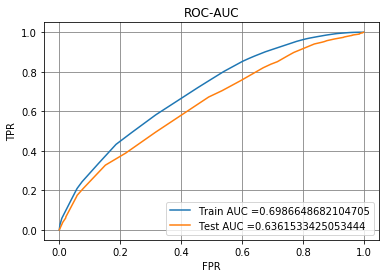

In [ ]:
plt.plot(train_fpr, train_tpr, label="Train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="Test AUC ="+str(auc(test_fpr, test_tpr)))

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC")
plt.grid(color = 'gray')
plt.show()

## <span style='color:Blue'>Confusion matrix for set1</span>

To compute C.matrix,need actual values and predicted values,but here there are probability scores.Therefore need to find best threshold value so that class labels are predicted based on best threshold.

In [ ]:
## function to find optimal threshold on train data(threshold with least FPR)

def find_best_threshold(threshold, fpr, tpr):
    t = threshold[np.argmax(tpr*(1-fpr))]# np.argmax is to find the index of threshold that has (tpr*(1-fpr)) maximum
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

In [ ]:
best_threshold_set1 = find_best_threshold(train_threshold, train_fpr, train_tpr)

the maximum value of tpr*(1-fpr) 0.3977029006234255 for threshold 0.856


In [ ]:
# To make predictions on test data with best threshold obtained from above train data
def predict_with_best_t(proba, threshold):
    predictions = []
    for i in proba:
        if i>=threshold:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

C.Matrix for test data
      0     1
0  1804   838
1  6994  6864


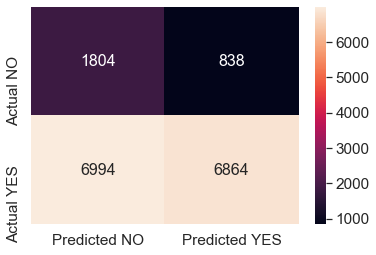

In [ ]:
#Confusion matrix for test data using best threshold obtained on train data
print('C.Matrix for test data')
test_con_matrix = pd.DataFrame(confusion_matrix(y_test, predict_with_best_t(y_test_pred_proba,best_threshold_set1)))
print(test_con_matrix)
test_con_matrix.columns = ['Predicted NO','Predicted YES']
test_con_matrix = test_con_matrix.rename({0: 'Actual NO', 1: 'Actual YES'})
sns.set(font_scale=1.4)
sns.heatmap(test_con_matrix, annot=True,annot_kws={"size": 16}, fmt='g')

Observations:

TN = 1804
FN = 6994
FP = 838
TP = 6864
True positives are highest of all

### <span style='color:Blue'>Plot the WordCloud with the words of essay text of these false positive data points</span>
### <span style='color:Blue'>Plot the box plot with the price of these false positive data points</span>
### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of these false positive data points </span>

https://www.geeksforgeeks.org/generating-word-cloud-python/

Word cloud of FP datapoints indicates what all words made model to give FP

In [ ]:
# Extract false positive data points of test data for essay,price,teacher_number_of_previously_posted_projects

FP_essay=[]
FP_price=[]
FP_previous_posted=[]

#predictions= predict_with_best_t(proba, threshold)
predictions= predict_with_best_t(y_test_pred_proba, best_threshold_set1)
#print(type(predictions))
#proba=y_test_pred_proba
#threshold=best_threshold_set1
y_test_list = list(y_test[::])#to avoid AttributeError: 'numpy.ndarray' object has no attribute 'values' while using y_test.values[i]==0
FP_test_indexes =[]

for i in range(len(y_test)):
    if(y_test_list[i]==0 and predictions[i]==1):
        FP_test_indexes.append(i)

for i in FP_test_indexes:
    FP_essay.append(x_test['essay'].values[i])
    FP_price.append(x_test['price'].values[i])
    FP_previous_posted.append(x_test['teacher_number_of_previously_posted_projects'].values[i])



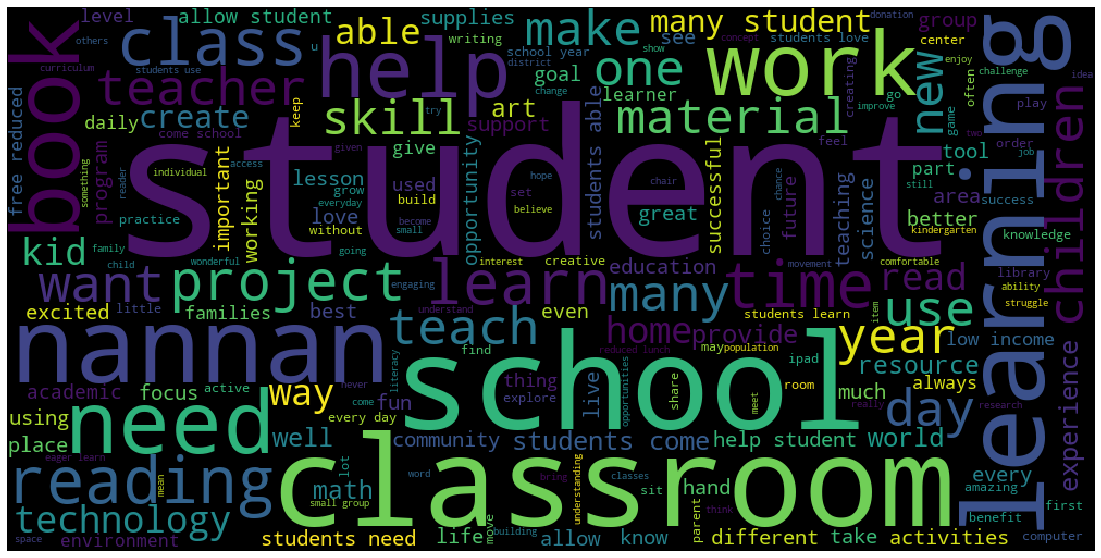

In [ ]:
# REF: https://github.com/AnveshAeturi/Decision-Tree-on-Donors-Choose-Dataset/blob/master/8_DonorsChoose_DT.ipynb
#from wordcloud import WordCloud
#from wordcloud import STOPWORDS
#convert list to string and generate
words_string=(" ").join(FP_essay)
wordcloud = WordCloud(width = 1000, height = 500).generate(words_string)
plt.figure(figsize=(25,10))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

###  <span style='color:Blue'> Observations: </span>

Student , classroom,learning, school are the prominent words in an image.

Not seeing any stop words

### <span style='color:Blue'>Plot the box plot with the price of false positive data points</span>

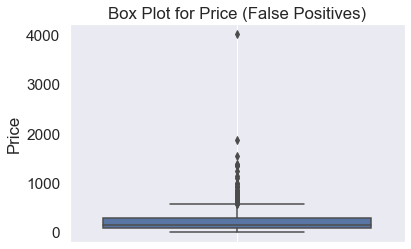

In [ ]:
sns.boxplot(y=FP_price)
plt.title('Box Plot for Price (False Positives)')
plt.ylabel('Price')
plt.grid()
plt.show()


### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of false positive data points </span>

No handles with labels found to put in legend.


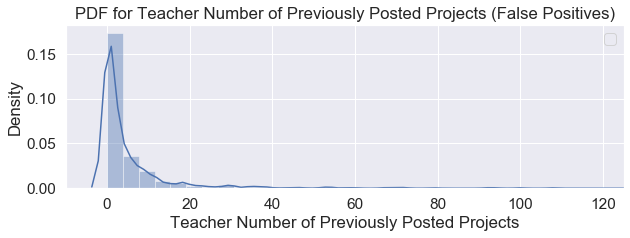

In [ ]:
plt.figure(figsize=(10,3))
sns.distplot(FP_previous_posted)
plt.title('PDF for Teacher Number of Previously Posted Projects (False Positives)')
plt.xlabel('Teacher Number of Previously Posted Projects')
plt.ylabel('Density')
plt.xlim(-10,125)
plt.legend()
plt.show()

###  <span style='color:Blue'>Observation:</span>

Density is high from 0.0 to 0.10 which indicates high False Positives are there.

###   <span style='color:Blue'>Hyperparameter Tunning GridSearch on TFIDF W2V </span>

In [ ]:
DT_on_tfidfw2v = DecisionTreeClassifier(class_weight= 'balanced',random_state=0) # to make imbalance data to balnced data

parameters = {'max_depth': [1, 5, 10, 50], 'min_samples_split': [5, 10,100,500]}

hyper_para_tuning_tfidfw2v = GridSearchCV(DT_on_tfidfw2v, parameters, cv=3, scoring='roc_auc',n_jobs=-1,return_train_score=True)

hyper_para_tuning_tfidfw2v.fit(x_train_TFIDF_w2v_hstac, y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                              class_weight='balanced',
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'max_depth': [1, 5, 10, 50],
                       

In [ ]:
best_max_depth_tfidfw2v=hyper_para_tuning_tfidfw2v.best_params_["max_depth"]
best_max_depth_tfidfw2v

5

In [ ]:
bestmin_samples_split_tfidfw2v=hyper_para_tuning_tfidfw2v.best_params_["min_samples_split"]
bestmin_samples_split_tfidfw2v

500

In [ ]:
y_train_pred_tfidfw2v = hyper_para_tuning_tfidfw2v.predict_proba(x_train_TFIDF_w2v_hstac)[:,1]
y_train_pred_tfidfw2v

array([0.83970805, 0.36053414, 0.36455458, ..., 0.73285628, 0.58826659,
       0.36053414])

In [ ]:
results_tfidfw2v=pd.DataFrame.from_dict(hyper_para_tuning_tfidfw2v.cv_results_)
results_tfidfw2v.head(1)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,1.780313,0.051159,0.049971,0.006477,1,5,"{'max_depth': 1, 'min_samples_split': 5}",0.556994,0.562004,0.569617,0.562872,0.00519,11,0.569979,0.565732,0.561097,0.565603,0.003627


In [ ]:
Xaxis_train_min_samp_split=list(results_tfidfw2v['param_min_samples_split'])
Yaxis_train_max_depth=list(results_tfidfw2v['param_max_depth'])
Zaxis_train_AUC_score=list(results_tfidfw2v['mean_train_score'])

Xaxis_cv_min_samp_split=list(results_tfidfw2v['param_min_samples_split'])
Yaxis_cv_max_depth=list(results_tfidfw2v['param_max_depth'])
Zaxis_cv_AUC_score=list(results_tfidfw2v['mean_test_score'])

In [ ]:
trace1 = go.Scatter3d(x=Xaxis_train_min_samp_split,y=Yaxis_train_max_depth,z=Zaxis_train_AUC_score, name = 'train')
trace2 = go.Scatter3d(x=Xaxis_cv_min_samp_split,y=Yaxis_cv_max_depth,z=Zaxis_cv_AUC_score, name = 'Cross validation')
data = [trace1, trace2]

layout = go.Layout(scene = dict(
        xaxis = dict(title='min_sample_split'),
        yaxis = dict(title='max_depth'),
        zaxis = dict(title='AUC'),))

fig = go.Figure(data=data, layout=layout)
offline.iplot(fig, filename='3d-scatter-colorscale')

## <span style='color:Blue'>Train the set 2 train data with best "max_depth" and "min_samples_split"</span>

In [ ]:
DT_classifier_set2 = DecisionTreeClassifier(max_depth=best_max_depth_tfidfw2v,min_samples_split=bestmin_samples_split_tfidfw2v,random_state=0)

DT_classifier_set2.fit(x_train_TFIDF_w2v_hstac,y_train)

y_train_predict_proba_tfidfw2v=DT_classifier_set2.predict_proba(x_train_TFIDF_w2v_hstac)[:,1]

tfidfw2v_train_fpr, tfidfw2v_train_tpr, tfidfw2v_train_threshold = roc_curve(y_train,y_train_predict_proba_tfidfw2v)

### <span style='color:Blue'>Test the set2 test data with Decision Tree using best "max_depth" and "min_samples_split"</span>

In [ ]:
y_test_pred_proba_tfidfw2v=DT_classifier_set2.predict_proba(x_test_TFIDF_w2v_hstac)[:,1]
tfidfw2v_test_fpr, tfidfw2v_test_tpr, tfidfw2v_test_threshold = roc_curve(y_test,y_test_pred_proba_tfidfw2v)

## <span style='color:Blue'>Plot the ROC & AUC curve on both train and test of set2</span>

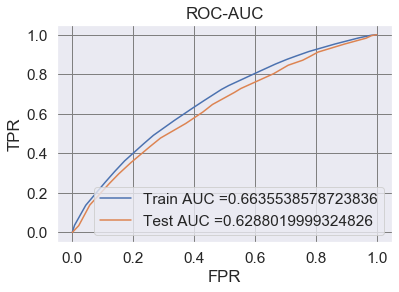

In [ ]:
plt.plot(tfidfw2v_train_fpr,tfidfw2v_train_tpr, label="Train AUC ="+str(auc(tfidfw2v_train_fpr, tfidfw2v_train_tpr)))
plt.plot(tfidfw2v_test_fpr,tfidfw2v_test_tpr, label="Test AUC ="+str(auc(tfidfw2v_test_fpr,tfidfw2v_test_tpr)))

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC")
plt.grid(color = 'gray')
plt.show()

## <span style='color:Blue'>Confusion matrix for set2</span>

In [ ]:
# to find optimal threshold on train data(threshold with least FPR)
best_threshold_set2 = find_best_threshold(train_threshold, train_fpr, train_tpr)
train_threshold=  tfidfw2v_train_threshold
train_fpr = tfidfw2v_train_fpr
train_tpr =  tfidfw2v_train_tpr

the maximum value of tpr*(1-fpr) 0.3977029006234255 for threshold 0.856


C.Matrix for test data
      0     1
0  1876   766
1  7241  6617


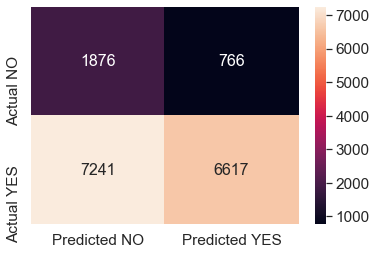

In [ ]:
#Confusion matrix for tfidfw2v test data using best threshold obtained on train data
print('C.Matrix for test data')
tfidfw2v_test_con_matrix = pd.DataFrame(confusion_matrix(y_test, predict_with_best_t(y_test_pred_proba_tfidfw2v,best_threshold_set2)))
print(tfidfw2v_test_con_matrix)
tfidfw2v_test_con_matrix.columns = ['Predicted NO','Predicted YES']
tfidfw2v_test_con_matrix= tfidfw2v_test_con_matrix.rename({0: 'Actual NO', 1: 'Actual YES'})
sns.set(font_scale=1.4)
sns.heatmap(tfidfw2v_test_con_matrix, annot=True,annot_kws={"size": 16}, fmt='g')

Observations:

TN = 1876
FN = 7241
FP = 766
TP = 6617
True positives are highest of all

### <span style='color:Blue'>Plot the WordCloud with the tfidfw2v words of essay text of false positive data points</span>
### <span style='color:Blue'>Plot the box plot with the price of these false positive data points</span>
### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of these false positive data points </span>

In [ ]:
tfidfw2v_FP_essay=[]
tfidfw2v_FP_price=[]
tfidfw2v_FP_previous_posted=[]

#predictions= predict_with_best_t(proba, threshold)
tfidfw2v_predictions= predict_with_best_t(y_test_pred_proba_tfidfw2v, best_threshold_set2)
#proba=y_test_pred_proba_tfidfw2v
#threshold=best_threshold_set2
y_test_list_tfidfw2v = list(y_test[::])#to avoid AttributeError: 'numpy.ndarray' object has no attribute 'values' while using y_test.values[i]==0
tfidfw2v_FP_test_indexes =[]

for i in range(len(y_test)):
    if(y_test_list_tfidfw2v[i]==0 and tfidfw2v_predictions[i]==1):
        tfidfw2v_FP_test_indexes.append(i)

for i in tfidfw2v_FP_test_indexes:
    tfidfw2v_FP_essay.append(x_test['essay'].values[i])
    tfidfw2v_FP_price.append(x_test['price'].values[i])
    tfidfw2v_FP_previous_posted.append(x_test['teacher_number_of_previously_posted_projects'].values[i])

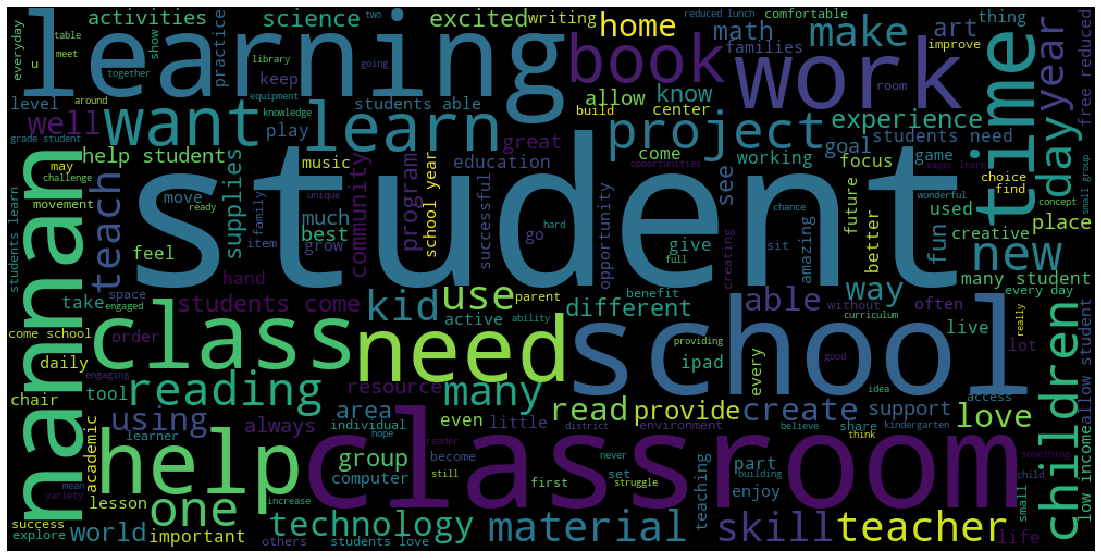

In [ ]:
words_string=(" ").join(tfidfw2v_FP_essay)
wordcloud = WordCloud(width = 1000, height = 500).generate(words_string)
plt.figure(figsize=(25,10))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

###  <span style='color:Blue'>Observations:</span>

Student , classroom,learning, school are the prominent words in an image.

Not seeing any stop words

### <span style='color:Blue'>Plot the box plot with the price of tfidfw2v false positive data points</span>

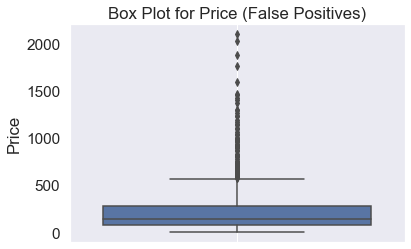

In [ ]:
sns.boxplot(y=tfidfw2v_FP_price)
plt.title('Box Plot for Price (False Positives)')
plt.ylabel('Price')
plt.grid()
plt.show()

### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of tfidfw2v false positive data points </span>

No handles with labels found to put in legend.


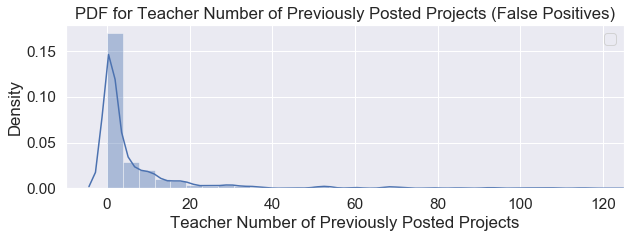

In [ ]:
plt.figure(figsize=(10,3))
sns.distplot(tfidfw2v_FP_previous_posted)
plt.title('PDF for Teacher Number of Previously Posted Projects (False Positives)')
plt.xlabel('Teacher Number of Previously Posted Projects')
plt.ylabel('Density')
plt.xlim(-10,125)
plt.legend()
plt.show()

###  <span style='color:Blue'>Observation: </span>

Density is high from 0.00 to 0.10 i.e high False Positives.

# <font color='red'><b> Task - 2 </b></font>
For this task consider **set-1** features.

*  Select all the features which are having non-zero feature importance.You can get the feature importance using  'feature_importances_`
   (https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), discard the all other remaining features and then apply any of the model of you choice i.e. (Dession tree, Logistic Regression, Linear SVM).

In [ ]:
x_train_TFIDF_hstac.shape

(33500, 10442)

In [ ]:
x_train_TFIDF_hstac.shape[1]

10442

In [ ]:
dtc= DecisionTreeClassifier(class_weight='balanced',random_state=0)
fea_imp=dtc.fit(x_train_TFIDF_hstac, y_train).feature_importances_ # getting feature importance values
new_fea_train= x_train_TFIDF_hstac[:,fea_imp != 0]# selecting non-zero feature importance values
new_fea_train

<33500x1614 sparse matrix of type '<class 'numpy.float64'>'
	with 2878940 stored elements in Compressed Sparse Row format>

In [ ]:
new_fea_train.shape

(33500, 1614)

###  <span style='color:Blue'>non-zero feature importance for test data</span>

In [ ]:
x_test_TFIDF_hstac.shape

(16500, 10442)

In [ ]:
#trained model using train data and found out feature importances,prepare test data excluding those features which were
#having zero importance in train data
new_fea_test=x_test_TFIDF_hstac[:,fea_imp !=0]
new_fea_test

<16500x1614 sparse matrix of type '<class 'numpy.float64'>'
	with 1411875 stored elements in Compressed Sparse Row format>

In [ ]:
new_fea_test.shape

(16500, 1614)

###  <span style='color:Blue'>Hyperparameter tuning for non-zero feature importance values</span>

In [ ]:
dtc_nonzero = DecisionTreeClassifier(class_weight= 'balanced',random_state=0)#class_weight is to make imbalance data to balnced data

parameters = {'max_depth': [1, 5, 10, 50], 'min_samples_split': [5, 10,100,500]}

hpt_nonzero = GridSearchCV(dtc_nonzero, parameters, cv=3, scoring='roc_auc',n_jobs=-1,return_train_score=True)

hpt_nonzero.fit(new_fea_train,y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                              class_weight='balanced',
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'max_depth': [1, 5, 10, 50],
                       

In [ ]:
best_nonzero_max_depth=hpt_nonzero.best_params_["max_depth"]
best_nonzero_max_depth

10

In [ ]:
best_nonzero_min_samples_split=hpt_nonzero.best_params_["min_samples_split"]
best_nonzero_min_samples_split

500

In [ ]:
hpt_nonzero.best_score_

0.6416669995557371

In [ ]:
y_train_pred_nonzero = hpt_nonzero.predict_proba(new_fea_train)[:,1]
y_train_pred_nonzero

array([0.87731252, 0.39393673, 0.14481828, ..., 0.47269944, 0.68742825,
       0.79162702])

In [ ]:
results_nonzero=pd.DataFrame.from_dict(hpt_nonzero.cv_results_)
results_nonzero.head(1)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0.523034,0.03998,0.021655,0.009459,1,5,"{'max_depth': 1, 'min_samples_split': 5}",0.556994,0.562004,0.569617,0.562872,0.00519,11,0.569979,0.565732,0.561097,0.565603,0.003627


In [ ]:
Xaxis_train_nonzero_min_samp_split=results_nonzero['param_min_samples_split']
Yaxis_train_nonzero_max_depth=results_nonzero['param_max_depth']
Zaxis_train_nonzero_AUC_score=results_nonzero['mean_train_score']

Xaxis_cv_nonzero_min_samp_split=results_nonzero['param_min_samples_split']
Yaxis_cv_nonzero_max_depth=results_nonzero['param_max_depth']
Zaxis_cv_nonzero_AUC_score=results_nonzero['mean_test_score']

x1= list(Xaxis_train_nonzero_min_samp_split)
y1=list(Yaxis_train_nonzero_max_depth)
z1=list(Zaxis_train_nonzero_AUC_score)

x2=list(Xaxis_cv_nonzero_min_samp_split)
y2=list(Yaxis_train_nonzero_max_depth)
z2=list(Zaxis_cv_nonzero_AUC_score)

In [ ]:
trace1 = go.Scatter3d(x=x1,y=y1,z=z1, name = 'train')
trace2 = go.Scatter3d(x=x2,y=y2,z=z2, name = 'Cross validation')
data = [trace1, trace2]

layout = go.Layout(scene = dict(
        xaxis = dict(title='min_sample_split'),
        yaxis = dict(title='max_depth'),
        zaxis = dict(title='AUC'),))

fig = go.Figure(data=data, layout=layout)
offline.iplot(fig, filename='3d-scatter-colorscale')

## <span style='color:Blue'>Train the new_fea_train  data with best "max_depth" and "min_samples_split"</span>

In [ ]:
dtc_nonzero_best = DecisionTreeClassifier(max_depth=best_nonzero_max_depth,min_samples_split=best_nonzero_min_samples_split,random_state=0)

dtc_nonzero_best.fit(new_fea_train,y_train)

y_train_nonzero_predict_proba=dtc_nonzero_best.predict_proba(new_fea_train)[:,1]

nonzero_train_fpr, nonzero_train_tpr, nonzero_train_threshold = roc_curve(y_train,y_train_nonzero_predict_proba)

### <span style='color:Blue'>Test new_fea_test data with Decision Tree using best "max_depth" and "min_samples_split"</span>

In [ ]:
y_test_nonzero_pred_proba=dtc_nonzero_best.predict_proba(new_fea_test)[:,1]
nonzero_test_fpr, nonzero_test_tpr, nonzero_test_threshold = roc_curve(y_test, y_test_nonzero_pred_proba)

## <span style='color:Blue'>Plot the ROC & AUC curve on both new_fea_train and new_fea_test </span>

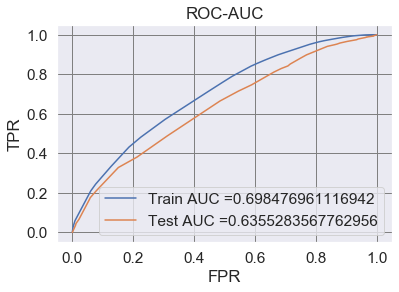

In [ ]:
plt.plot(nonzero_train_fpr, nonzero_train_tpr, label="Train AUC ="+str(auc(nonzero_train_fpr, nonzero_train_tpr)))
plt.plot(nonzero_test_fpr, nonzero_test_tpr, label="Test AUC ="+str(auc(nonzero_test_fpr, nonzero_test_tpr)))

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC")
plt.grid(color = 'gray')
plt.show()

## <span style='color:Blue'>Confusion matrix for nonzero features </span>
find best threshold value so that class labels are predicted based on best threshold.

In [ ]:
best_threshold = find_best_threshold(nonzero_train_threshold, nonzero_train_fpr, nonzero_train_tpr)

the maximum value of tpr*(1-fpr) 0.3975860893034863 for threshold 0.855


C.Matrix for non-zero feature test data
      0     1
0  1819   823
1  7100  6758


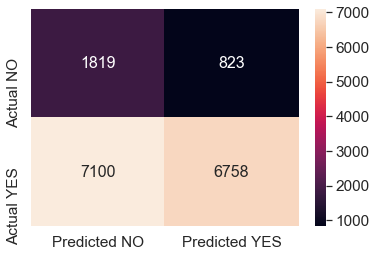

In [ ]:
#Confusion matrix for test data using best threshold obtained on train data
print('C.Matrix for non-zero feature test data')
nonzero_fea_test_con_matrix = pd.DataFrame(confusion_matrix(y_test, predict_with_best_t(y_test_nonzero_pred_proba,best_threshold)))
print(nonzero_fea_test_con_matrix)
nonzero_fea_test_con_matrix.columns = ['Predicted NO','Predicted YES']
nonzero_fea_test_con_matrix = nonzero_fea_test_con_matrix.rename({0: 'Actual NO', 1: 'Actual YES'})
sns.set(font_scale=1.4)
sns.heatmap(nonzero_fea_test_con_matrix, annot=True,annot_kws={"size": 16}, fmt='g')

 <span style='color:Blue'>Observations:</span>

TN = 1819
FN = 7100
FP = 823
TP = 6758
True positives are highest of all

### <span style='color:Blue'>Plot the WordCloud with the words of essay text of these nonzero false positive data points</span>
### <span style='color:Blue'>Plot the box plot with the price of these nonzero false positive data points</span>
### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of these nonzero false positive data points </span>

In [ ]:
nonzero_FP_essay=[]
nonzero_FP_price=[]
nonzero_FP_previous_posted=[]

#predictions= predict_with_best_t(proba, threshold)
predictions= predict_with_best_t(y_test_nonzero_pred_proba, best_threshold)
y_nonzero_test_list = list(y_test[::])#to avoid AttributeError: 'numpy.ndarray' object has no attribute 'values' while using y_test.values[i]==0
FP_nonzero_test_indexes =[]

for i in range(len(y_test)):
    if(y_nonzero_test_list[i]==0 and predictions[i]==1):
        FP_nonzero_test_indexes.append(i)

for i in FP_test_indexes:
    nonzero_FP_essay.append(x_test['essay'].values[i])
    nonzero_FP_price.append(x_test['price'].values[i])
    nonzero_FP_previous_posted.append(x_test['teacher_number_of_previously_posted_projects'].values[i])


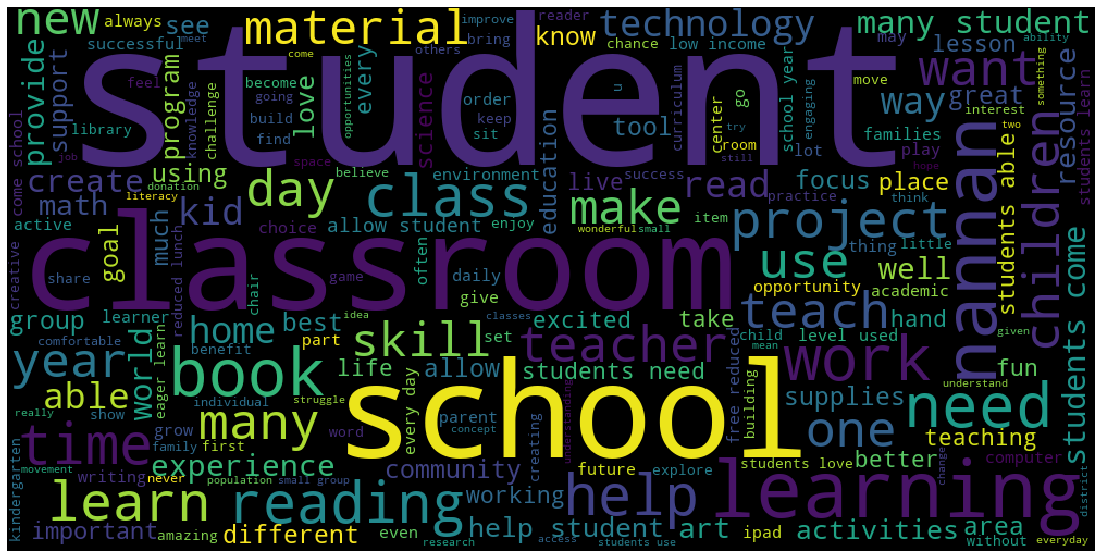

In [ ]:
words_string=(" ").join(FP_essay)
wordcloud = WordCloud(width = 1000, height = 500).generate(words_string)
plt.figure(figsize=(25,10))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

###  <span style='color:Blue'>Observation:</span>

words like Student, Classroom, learning ,school are prominent

### <span style='color:Blue'>Plot the box plot with the price of nonzero false positive data points</span>

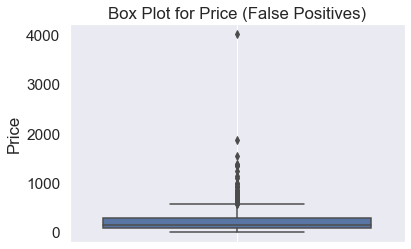

In [ ]:
sns.boxplot(y=nonzero_FP_price)
plt.title('Box Plot for Price (False Positives)')
plt.ylabel('Price')
plt.grid()
plt.show()

### <span style='color:Blue'>Plot the pdf with the teacher_number_of_previously_posted_projects of nonzero false positive data points </span>

No handles with labels found to put in legend.


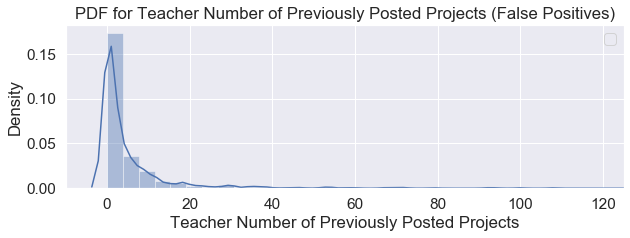

In [ ]:
plt.figure(figsize=(10,3))
sns.distplot(nonzero_FP_previous_posted)
plt.title('PDF for Teacher Number of Previously Posted Projects (False Positives)')
plt.xlabel('Teacher Number of Previously Posted Projects')
plt.ylabel('Density')
plt.xlim(-10,125)
plt.legend()
plt.show()

###  <span style='color:Blue'>Observation:</span>

Density is high from 0.00 to 0.10 i.e high False Positives.

###  <span style='color:Blue'>Summary</span>

In [ ]:
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ["Vectorizer","Min Sample Split","Max Depth", "Train AUC", "Test AUC"]
table.add_row(["TFIDF",bestmin_samples_split, best_max_depth,auc(train_fpr, train_tpr),auc(test_fpr, test_tpr)])
table.add_row(["TFIDF W2V",bestmin_samples_split_tfidfw2v, best_max_depth_tfidfw2v,auc(tfidfw2v_train_fpr, tfidfw2v_train_tpr),auc(tfidfw2v_test_fpr,tfidfw2v_test_tpr)])
table.add_row(["TFIDF(non-zero features)",best_nonzero_min_samples_split, best_nonzero_max_depth,auc(nonzero_train_fpr, nonzero_train_tpr),auc(nonzero_test_fpr, nonzero_test_tpr)])
print(table)

+--------------------------+------------------+-----------+--------------------+--------------------+
|        Vectorizer        | Min Sample Split | Max Depth |     Train AUC      |      Test AUC      |
+--------------------------+------------------+-----------+--------------------+--------------------+
|          TFIDF           |       500        |     10    | 0.6635538578723836 | 0.6361533425053444 |
|        TFIDF W2V         |       500        |     5     | 0.6635538578723836 | 0.6288019999324826 |
| TFIDF(non-zero features) |       500        |     10    | 0.698476961116942  | 0.6355283567762956 |
+--------------------------+------------------+-----------+--------------------+--------------------+


###  <span style='color:Blue'>Observation:</span>

AUC is the measure of a classifier ability to distinguish between classes and is used as a summary of the ROC curve.
Higher the AUC,better the performance of a model to distinguis between the positive and negative classes.

Train AUC is same for both TFIDF and TFIDF W2V but Test AUC differs slightly,
Train AUC is slightly differs for TFIDF(non-zero features) compared to TFIDF and TFIDF W2V. Test AUC is almost same as TFIDF but differs slightly with Test AUC of TFIDF W2V.
